  # Day 4 Model Training

This notebook starts the Day 4 modelling workflow using the clean monthly macro data prepared in Day 2. The first steps focus on setup, modelling QA, and a simple target-and-features decision before any model training begins.

It is important to note that annual income by decile is excluded from the Day 4 model because it is not frequency-compatible with the monthly target and including it directly would create false precision.


 ## 00_setup

Day 4 uses the Day 2 clean monthly macro file as the modelling base. This setup block defines imports, file paths, and output folders for any later model results or saved artifacts.


In [1]:
from pathlib import Path
import pickle
import matplotlib
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

ip = get_ipython()
if ip is None:
    matplotlib.use("Agg")  # keep script execution headless outside notebooks
else:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
outputs_dir = project_root / "outputs"

monthly_macro_file = processed_dir / "day2_merged_monthly_macro.csv"
random_state = 42

models_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Monthly macro file:", monthly_macro_file)
print("Models folder:", models_dir)
print("Outputs folder:", outputs_dir)


Monthly macro file: /Users/hongmiaozhu/PycharmProjects/Project /data/processed/day2_merged_monthly_macro.csv
Models folder: /Users/hongmiaozhu/PycharmProjects/Project /models
Outputs folder: /Users/hongmiaozhu/PycharmProjects/Project /outputs


## 01_load_model_data

This section loads the monthly macro dataset and checks whether it is clean enough for modelling. The goal is to confirm the usable date range, monthly structure, and whether the main modelling variables have any major missing-value problems.

One small modelling rule is used here: a single isolated missing value can usually be removed safely after lag creation, but larger gaps would weaken the modelling base and make the results less reliable.

This modelling base contains UK monthly macro variables only; annual income by decile is excluded from the Day 4 model because it is not frequency-compatible with the monthly target


In [2]:
model_data = pd.read_csv(monthly_macro_file)
model_data["year_month"] = pd.to_datetime(model_data["year_month"], format="%Y-%m")

print("Shape:", model_data.shape)
print("\nColumns:")
print(model_data.columns.tolist())
print("\nFirst rows:")
display(model_data.head())

print("\nDate range:", model_data["year_month"].min().strftime("%Y-%m"), "to", model_data["year_month"].max().strftime("%Y-%m"))

duplicate_months = model_data.duplicated(subset=["year_month"]).sum()
usable_monthly_rows = model_data["year_month"].dt.to_period("M").nunique() == len(model_data)

print("Duplicate year_month rows:", duplicate_months)
print("Usable monthly rows (one row per month):", usable_monthly_rows)

candidate_model_columns = ["house_price_index", "inflation_rate", "unemployment_rate", "bank_rate"]
missing_model_values = model_data[candidate_model_columns].isna().sum()

print("\nDtypes:")
print(model_data.dtypes)
print("\nMissing values in modelling variables:")
print(missing_model_values)

serious_issues = []
if duplicate_months > 0:
    serious_issues.append("duplicate monthly keys found")
if not usable_monthly_rows:
    serious_issues.append("data no longer has one usable row per month")
unexpected_missing = [col for col, value in missing_model_values.items() if value > 1]
if unexpected_missing:
    serious_issues.append(f"major missing values found in modelling variables: {unexpected_missing}")

if serious_issues:
    message = "Serious structural issue found. Fix it in main.py, not by patching this notebook.\n- " + "\n- ".join(serious_issues)
    raise ValueError(message)

print("\nModel-data QA summary:")
print("The monthly macro file is usable for modelling.")
print("The data keeps one row per month across the available window.")
print("There are no major missing-value problems in the main modelling variables.")
print("A single isolated missing value can usually be removed safely after lag creation, but larger gaps would weaken the modelling base.")


Shape: (59, 7)

Columns:
['year_month', 'inflation_rate', 'house_price_index', 'bank_rate', 'unemployment_rate', 'geo_name', 'source_note']

First rows:


,year_month,inflation_rate,house_price_index,bank_rate,unemployment_rate,geo_name,source_note
0,2021-03-01,1.000,89.100,0.100,4.800,UK,Merged monthly macro dataset from official ONS...
1,2021-04-01,1.600,87.800,0.100,4.800,UK,Merged monthly macro dataset from official ONS...
2,2021-05-01,2.100,88.300,0.100,4.700,UK,Merged monthly macro dataset from official ONS...
3,2021-06-01,2.400,93.000,0.100,4.600,UK,Merged monthly macro dataset from official ONS...
4,2021-07-01,2.100,88.700,0.100,4.500,UK,Merged monthly macro dataset from official ONS...



Date range: 2021-03 to 2026-01
Duplicate year_month rows: 0
Usable monthly rows (one row per month): True

Dtypes:
year_month           datetime64[us]
inflation_rate              float64
house_price_index           float64
bank_rate                   float64
unemployment_rate           float64
geo_name                        str
source_note                     str
dtype: object

Missing values in modelling variables:
house_price_index    0
inflation_rate       0
unemployment_rate    1
bank_rate            0
dtype: int64

Model-data QA summary:
The monthly macro file is usable for modelling.
The data keeps one row per month across the available window.
There are no major missing-value problems in the main modelling variables.
A single isolated missing value can usually be removed safely after lag creation, but larger gaps would weaken the modelling base.


## 02_target_and_features

This is the main modelling decision for Day 4.

**Target**
- `house_price_index`

This target was chosen because housing is central to the project’s research question on affordability, cost-of-living pressure, and economic vulnerability in the UK. A housing-price target is also compatible with the cleaned monthly macro dataset built on Day 2.

This does not mean the whole project is reduced to house prices only. The project still studies inequality through income deciles and policy interpretation, but Day 4 needs one clean monthly modelling target. `house_price_index` is acceptable for Day 4 because it connects directly to housing affordability pressure and is available at the same monthly frequency as the macro predictors.

**Analytical unit**
- monthly

**Candidate features**
- `inflation_rate`
- `unemployment_rate`
- `bank_rate`

The model uses lagged macro variables so that predictors come from information available before the target month. This makes the setup more realistic and reduces leakage risk.

**Final modelling rule**
- Use lagged versions of the explanatory variables to reduce leakage.

**Remove from the model input**
- identifiers such as `year_month`
- non-predictive metadata such as `geo_name` and `source_note`
- same-month explanatory columns that could leak the answer too directly into the model

The real feature creation happens in the next section so the modelling flow stays easier to follow.


In [3]:
target = "house_price_index"
candidate_features = ["inflation_rate", "unemployment_rate", "bank_rate"]
identifier_columns = ["year_month"]
non_predictive_columns = ["geo_name", "source_note"]
columns_removed_from_model_input = identifier_columns + non_predictive_columns + candidate_features

print("Target:", target)
print("Candidate features:", candidate_features)
print("Final modelling rule: use lagged explanatory variables to reduce leakage.")
print("Columns removed from model input:", columns_removed_from_model_input)
print("Next step: create the lagged features in Section 03.")


Target: house_price_index
Candidate features: ['inflation_rate', 'unemployment_rate', 'bank_rate']
Final modelling rule: use lagged explanatory variables to reduce leakage.
Columns removed from model input: ['year_month', 'geo_name', 'source_note', 'inflation_rate', 'unemployment_rate', 'bank_rate']
Next step: create the lagged features in Section 03.


## Decision Log

- `lag1` features were chosen because they are simple, reduce leakage risk by using only earlier-month information, and remain easy to interpret.
- `bank_rate_lag3` was added because Day 3 exploratory work suggested Bank Rate timing may matter beyond one month.
- Only these macro variables were kept because the dataset is limited, and Day 4 is meant to stay simple rather than expanding the feature set too early.
- Linear Regression is the baseline because it is interpretable and provides a clear benchmark for later comparisons.
- Random Forest is included as a non-linear comparison model only, without tuning, so the comparison stays straightforward.
- `random_state = 42` is fixed intentionally for reproducibility so repeated runs stay consistent and easier to compare.


## 03_feature_engineering

This section creates a small set of beginner-friendly features for the first model.

`lag1` is a reasonable starting assumption because monthly macro conditions can affect housing with a short delay while keeping the timing rule easy to explain. This notebook does not add many more lags yet because the sample is small, extra lag columns would reduce usable rows, and Day 4 should stay interpretable rather than overfit.

**Features created**
- `inflation_rate_lag1`: previous month's inflation rate
- `unemployment_rate_lag1`: previous month's unemployment rate
- `bank_rate_lag1`: previous month's Bank Rate
- `bank_rate_lag3` (optional): Bank Rate from three months earlier

**Why keep this simple**
- these features are easy to explain
- they respect time order
- they avoid adding many extra variables too early

**Time meaning**
- a lagged feature uses information from earlier months only
- this helps reduce leakage when predicting the current month's house price index
- a few early rows are dropped after lag creation because those months do not yet have enough history for all lagged features
- `bank_rate_lag3` is included as a simple extra comparison feature because Day 3 already suggested that Bank Rate timing may matter over more than one month

In [4]:
# Build the feature table from the modelling decision above.
modelling_base = model_data[["year_month", target] + candidate_features].copy()
modelling_base = modelling_base.sort_values("year_month").reset_index(drop=True)

# Leakage prevention: shift(n) slides the column down by n rows, so each row
# holds the value from n months ago. The target month never sees same-month or
# future macro values.
modelling_base["inflation_rate_lag1"] = modelling_base["inflation_rate"].shift(1)
modelling_base["unemployment_rate_lag1"] = modelling_base["unemployment_rate"].shift(1)
modelling_base["bank_rate_lag1"] = modelling_base["bank_rate"].shift(1)

# Extra lag based on the Day 3 exploratory finding that Bank Rate timing may matter.
modelling_base["bank_rate_lag3"] = modelling_base["bank_rate"].shift(3)

final_feature_columns = [
    "inflation_rate_lag1",
    "unemployment_rate_lag1",
    "bank_rate_lag1",
    "bank_rate_lag3",
]

feature_docs = pd.DataFrame([
    {
        "feature_name": "inflation_rate_lag1",
        "exact_formula": "inflation_rate.shift(1)",
        "lag_used": "t-1",
        "intuition": "Recent inflation pressure may affect housing-market conditions with a short delay.",
        "why_no_leakage": "Uses only the previous month's inflation value, not the target month's value.",
    },
    {
        "feature_name": "unemployment_rate_lag1",
        "exact_formula": "unemployment_rate.shift(1)",
        "lag_used": "t-1",
        "intuition": "Recent labour-market conditions may affect housing demand and affordability.",
        "why_no_leakage": "Uses only the previous month's unemployment value.",
    },
    {
        "feature_name": "bank_rate_lag1",
        "exact_formula": "bank_rate.shift(1)",
        "lag_used": "t-1",
        "intuition": "Recent monetary conditions may affect mortgage costs and buyer behaviour.",
        "why_no_leakage": "Uses only the previous month's Bank Rate.",
    },
    {
        "feature_name": "bank_rate_lag3",
        "exact_formula": "bank_rate.shift(3)",
        "lag_used": "t-3",
        "intuition": "Bank Rate may affect housing with a delayed transmission period.",
        "why_no_leakage": "Uses Bank Rate from three months earlier, so it cannot contain future information.",
    },
])

feature_ready = modelling_base[["year_month", target] + final_feature_columns].dropna().reset_index(drop=True)
feature_docs_output_file = outputs_dir / "day4_feature_documentation.csv"
feature_docs.to_csv(feature_docs_output_file, index=False)

print("Feature documentation:")
display(feature_docs)
print("Saved feature documentation to:", feature_docs_output_file)

print("\nFeature-ready shape:", feature_ready.shape)
print("\nFeature-ready preview:")
display(feature_ready.head())


Feature documentation:


,feature_name,exact_formula,lag_used,intuition,why_no_leakage
0,inflation_rate_lag1,inflation_rate.shift(1),t-1,Recent inflation pressure may affect housing-m...,Uses only the previous month's inflation value...
1,unemployment_rate_lag1,unemployment_rate.shift(1),t-1,Recent labour-market conditions may affect hou...,Uses only the previous month's unemployment va...
2,bank_rate_lag1,bank_rate.shift(1),t-1,Recent monetary conditions may affect mortgage...,Uses only the previous month's Bank Rate.
3,bank_rate_lag3,bank_rate.shift(3),t-3,Bank Rate may affect housing with a delayed tr...,"Uses Bank Rate from three months earlier, so i..."


Saved feature documentation to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day4_feature_documentation.csv

Feature-ready shape: (56, 6)

Feature-ready preview:


,year_month,house_price_index,inflation_rate_lag1,unemployment_rate_lag1,bank_rate_lag1,bank_rate_lag3
0,2021-06-01,93.000,2.100,4.700,0.100,0.100
1,2021-07-01,88.700,2.400,4.600,0.100,0.100
2,2021-08-01,91.400,2.100,4.500,0.100,0.100
3,2021-09-01,94.000,3.000,4.400,0.100,0.100
4,2021-10-01,91.700,2.900,4.300,0.100,0.100


## Leakage prevention

This modelling exercise uses a chronological split rather than a random split because the data are time-ordered. The first 80% of months are used for training and the final 20% are held out for testing.

Leakage controls used here:
- only lagged predictors enter the model
- no same-month macro values are used as predictors for the target month
- no future information enters the feature set
- no test-set information is used in preprocessing, feature selection, scaling, or transformation
- no random shuffling is applied before the split

This is intentionally simple: there is no scaler or learned preprocessing step fitted on the full dataset, so the test period remains a genuine unseen holdout for Day 5 evaluation.


## Feature summary

The table below documents the final features used in the Day 4 model, including their lag structure, interpretation, and modelling purpose.

In [5]:
print("Final feature documentation used for Day 4:")
display(feature_docs)


Final feature documentation used for Day 4:


,feature_name,exact_formula,lag_used,intuition,why_no_leakage
0,inflation_rate_lag1,inflation_rate.shift(1),t-1,Recent inflation pressure may affect housing-m...,Uses only the previous month's inflation value...
1,unemployment_rate_lag1,unemployment_rate.shift(1),t-1,Recent labour-market conditions may affect hou...,Uses only the previous month's unemployment va...
2,bank_rate_lag1,bank_rate.shift(1),t-1,Recent monetary conditions may affect mortgage...,Uses only the previous month's Bank Rate.
3,bank_rate_lag3,bank_rate.shift(3),t-3,Bank Rate may affect housing with a delayed tr...,"Uses Bank Rate from three months earlier, so i..."


## 04_train_test_split

For this time-series problem, the split should stay chronological.

**Rule used**
- first 80% of months = training set
- last 20% of months = test set
- do not shuffle the rows

This keeps the most recent months for testing and helps avoid leaking future information into the training stage. The holdout test set remains untouched until final evaluation.

The test window contains the most recent 12 months, so the evaluation mimics a genuine out-of-sample forecasting exercise rather than a random reshuffle

In [6]:
# Use a chronological 80/20 split for the time-series data.
split_index = int(len(feature_ready) * 0.8)

train_data = feature_ready.iloc[:split_index].copy()
test_data = feature_ready.iloc[split_index:].copy()

X_train = train_data[final_feature_columns].copy()
y_train = train_data[target].copy()
X_test = test_data[final_feature_columns].copy()
y_test = test_data[target].copy()

print("Split rule: first 80% train, last 20% test, no shuffle")
print("Train rows:", len(train_data))
print("Test rows:", len(test_data))
print("\nTrain date range:", train_data["year_month"].min().strftime("%Y-%m"), "to", train_data["year_month"].max().strftime("%Y-%m"))
print("Test date range:", test_data["year_month"].min().strftime("%Y-%m"), "to", test_data["year_month"].max().strftime("%Y-%m"))
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain preview:")
display(train_data.head())
print("\nTest preview:")
display(test_data.head())


Split rule: first 80% train, last 20% test, no shuffle
Train rows: 44
Test rows: 12

Train date range: 2021-06 to 2025-01
Test date range: 2025-02 to 2026-01

X_train shape: (44, 4)
X_test shape: (12, 4)
y_train shape: (44,)
y_test shape: (12,)

Train preview:


,year_month,house_price_index,inflation_rate_lag1,unemployment_rate_lag1,bank_rate_lag1,bank_rate_lag3
0,2021-06-01,93.000,2.100,4.700,0.100,0.100
1,2021-07-01,88.700,2.400,4.600,0.100,0.100
2,2021-08-01,91.400,2.100,4.500,0.100,0.100
3,2021-09-01,94.000,3.000,4.400,0.100,0.100
4,2021-10-01,91.700,2.900,4.300,0.100,0.100



Test preview:


,year_month,house_price_index,inflation_rate_lag1,unemployment_rate_lag1,bank_rate_lag1,bank_rate_lag3
44,2025-02-01,101.400,3.900,4.400,4.750,4.750
45,2025-03-01,102.800,3.700,4.500,4.500,4.750
46,2025-04-01,99.900,3.400,4.600,4.500,4.750
47,2025-05-01,101.300,4.100,4.700,4.500,4.500
48,2025-06-01,102.500,4.000,4.700,4.250,4.500


## Reproducibility Note

`random_state` is fixed intentionally at `42` whenever the workflow uses randomness. This keeps results consistent across runs and makes reproducibility explicit, which is a core requirement in a reliable ML workflow.


## 05_linear_baseline

This section fits the first baseline model for Day 4: multiple linear regression.

**Why start here**
- it is easy to explain
- it gives a simple benchmark for later models
- it fits the project goal of starting with an interpretable baseline

A small sklearn `Pipeline` is used only to keep the model structure tidy and reproducible. In practice, you can think of it as one `LinearRegression` model inside a simple wrapper.

The model is trained on the chronological training set and then evaluated on both the training and test sets.


Linear baseline metrics:


,MAE,RMSE,R2
train,1.553,1.805,0.682
test,6.377,6.783,-28.506



Linear baseline coefficients:


,feature,coefficient
0,intercept,109.225
1,inflation_rate_lag1,0.408
2,unemployment_rate_lag1,-3.961
3,bank_rate_lag1,-0.150
4,bank_rate_lag3,1.224


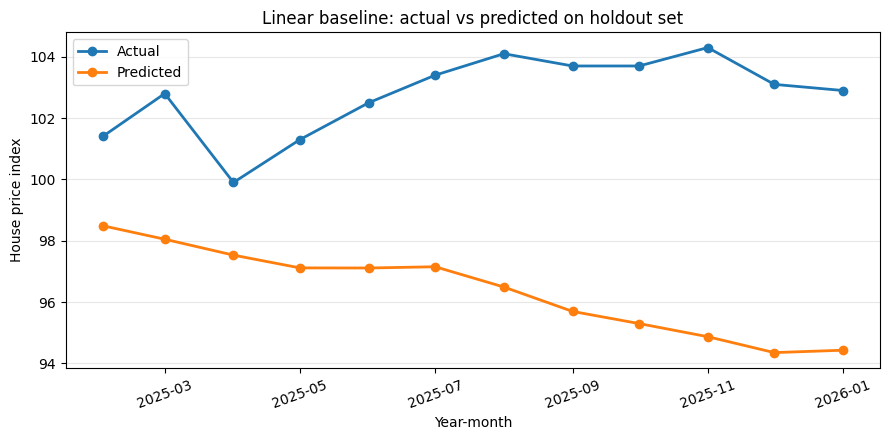

Saved model to: /Users/hongmiaozhu/PycharmProjects/Project /models/day4_linear_regression.pkl
Saved holdout predictions to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day4_holdout_predictions.csv
Saved figure to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day4_linear_actual_vs_predicted.png

Holdout prediction preview:


,year_month,actual_house_price_index,predicted_house_price_index,split
44,2025-02-01,101.400,98.490,test
45,2025-03-01,102.800,98.049,test
46,2025-04-01,99.900,97.531,test
47,2025-05-01,101.300,97.114,test
48,2025-06-01,102.500,97.111,test


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Wrap the baseline in a minimal pipeline so the training structure stays consistent.
linear_model = Pipeline([("model", LinearRegression())])
linear_model.fit(X_train, y_train)

linear_estimator = linear_model.named_steps["model"]

# Extract coefficients for display.
linear_intercept = linear_estimator.intercept_
linear_feature_coefs = linear_estimator.coef_

# Generate predictions on train and test sets.
train_predictions = linear_model.predict(X_train)
test_predictions = linear_model.predict(X_test)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)  # total unexplained error from the model
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)  # total variance if you just predicted the mean every time
    # R² = 1 means perfect predictions; R² = 0 means no better than the mean; negative means worse than the mean.
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

train_metrics = regression_metrics(y_train, train_predictions)
test_metrics = regression_metrics(y_test, test_predictions)

metrics_table = pd.DataFrame([train_metrics, test_metrics], index=["train", "test"]).round(3)
coefficient_table = pd.DataFrame(
    {
        "feature": ["intercept"] + final_feature_columns,
        "coefficient": [linear_estimator.intercept_] + linear_estimator.coef_.tolist(),
    }
).round(4)

train_predictions_df = pd.DataFrame(
    {
        "year_month": train_data["year_month"],
        "actual_house_price_index": y_train,
        "predicted_house_price_index": train_predictions,
        "split": "train",
    }
)

holdout_predictions_df = pd.DataFrame(
    {
        "year_month": test_data["year_month"],
        "actual_house_price_index": y_test,
        "predicted_house_price_index": test_predictions,
        "split": "test",
    }
)

model_output_file = models_dir / "day4_linear_regression.pkl"
with open(model_output_file, "wb") as f:
    pickle.dump(linear_model, f)

holdout_predictions_output_file = outputs_dir / "day4_holdout_predictions.csv"
holdout_predictions_df.to_csv(holdout_predictions_output_file, index=False)

print("Linear baseline metrics:")
display(metrics_table)

print("\nLinear baseline coefficients:")
display(coefficient_table)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(holdout_predictions_df["year_month"], holdout_predictions_df["actual_house_price_index"], marker="o", linewidth=2, label="Actual")
ax.plot(holdout_predictions_df["year_month"], holdout_predictions_df["predicted_house_price_index"], marker="o", linewidth=2, label="Predicted")
ax.set_title("Linear baseline: actual vs predicted on holdout set")
ax.set_xlabel("Year-month")
ax.set_ylabel("House price index")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
linear_baseline_plot_file = outputs_dir / "day4_linear_actual_vs_predicted.png"
plt.savefig(linear_baseline_plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved model to:", model_output_file)
print("Saved holdout predictions to:", holdout_predictions_output_file)
print("Saved figure to:", linear_baseline_plot_file)
print("\nHoldout prediction preview:")
display(holdout_predictions_df.head())


A lower `MAE` or `RMSE` means better predictive fit on that split. If the test metrics are close to the train metrics, the train/test gap is acceptable and the baseline generalizes reasonably to unseen months. A large gap — where train performance is much better than test — would suggest the model is memorising the training period rather than picking up a general pattern. The coefficients should be read as descriptive model weights, not causal effects: a positive coefficient on a feature means the model associates a higher value of that feature with a higher house price index in this dataset, not that the feature causes house prices to rise.

### Linear baseline interpretation

The linear regression baseline fits the training period reasonably well, but it performs poorly on the holdout period. The large train-test gap and strongly negative test R² show that the baseline does not generalise well to unseen months.

This means the linear model is still useful as a benchmark, but it should not be treated as a reliable forecasting tool in its current form.

## 06_random_forest_candidate

This section adds Random Forest only as a comparison model, not as the main model. It keeps the comparison fair by using the same target, the same final feature set, and the same chronological 80/20 split already created for the linear baseline.

No earlier modelling choices are changed here.


Random Forest metrics:


,MAE,RMSE,R2
train,0.385,0.495,0.976
test,3.371,3.616,-7.386



Random Forest feature importances:


,feature,importance
0,bank_rate_lag3,0.428
1,bank_rate_lag1,0.399
2,inflation_rate_lag1,0.128
3,unemployment_rate_lag1,0.046



Fair comparison on the same holdout set:


,MAE,RMSE,R2
linear_baseline_test,6.377,6.783,-28.506
random_forest_test,3.371,3.616,-7.386


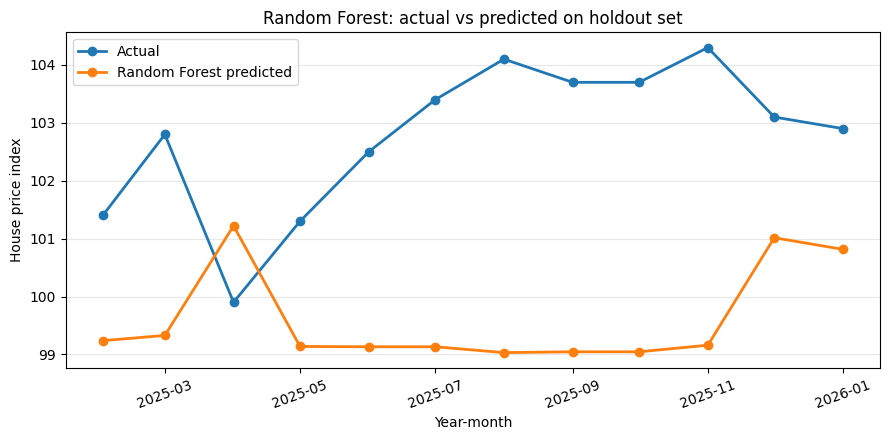

Saved comparison model to: /Users/hongmiaozhu/PycharmProjects/Project /models/day4_random_forest.pkl
Saved holdout predictions to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day4_rf_holdout_predictions.csv
Saved figure to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day4_rf_actual_vs_predicted.png

Random Forest holdout preview:


,year_month,actual_house_price_index,predicted_house_price_index,split
44,2025-02-01,101.400,99.237,test
45,2025-03-01,102.800,99.327,test
46,2025-04-01,99.900,101.221,test
47,2025-05-01,101.300,99.137,test
48,2025-06-01,102.500,99.132,test


In [8]:
try:
    from sklearn.ensemble import RandomForestRegressor
except ImportError as exc:
    raise ImportError(
        "Random Forest requires scikit-learn. Install scikit-learn in the project environment before running this cell."
    ) from exc

# Simple comparison model only: no heavy tuning.
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=random_state,
)

random_forest_model.fit(X_train, y_train)

rf_train_predictions = random_forest_model.predict(X_train)
rf_test_predictions = random_forest_model.predict(X_test)

rf_train_metrics = regression_metrics(y_train, rf_train_predictions)
rf_test_metrics = regression_metrics(y_test, rf_test_predictions)
rf_metrics_table = pd.DataFrame([rf_train_metrics, rf_test_metrics], index=["train", "test"]).round(3)

# feature_importances_ shows how much each variable contributed to the forest's decisions.
# Values sum to 1.0; a higher number means the model relied on that feature more.
rf_feature_importance = pd.DataFrame(
    {
        "feature": final_feature_columns,
        "importance": random_forest_model.feature_importances_,
    }
).sort_values("importance", ascending=False).reset_index(drop=True)

rf_holdout_predictions_df = pd.DataFrame(
    {
        "year_month": test_data["year_month"],
        "actual_house_price_index": y_test,
        "predicted_house_price_index": rf_test_predictions,
        "split": "test",
    }
)

rf_model_output_file = models_dir / "day4_random_forest.pkl"
with open(rf_model_output_file, "wb") as f:
    pickle.dump(random_forest_model, f)

rf_holdout_predictions_output_file = outputs_dir / "day4_rf_holdout_predictions.csv"
rf_holdout_predictions_df.to_csv(rf_holdout_predictions_output_file, index=False)

rf_vs_linear_test_metrics = pd.DataFrame(
    [test_metrics, rf_test_metrics],
    index=["linear_baseline_test", "random_forest_test"],
).round(3)

print("Random Forest metrics:")
display(rf_metrics_table)

print("\nRandom Forest feature importances:")
display(rf_feature_importance)

print("\nFair comparison on the same holdout set:")
display(rf_vs_linear_test_metrics)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rf_holdout_predictions_df["year_month"], rf_holdout_predictions_df["actual_house_price_index"], marker="o", linewidth=2, label="Actual")
ax.plot(rf_holdout_predictions_df["year_month"], rf_holdout_predictions_df["predicted_house_price_index"], marker="o", linewidth=2, label="Random Forest predicted")
ax.set_title("Random Forest: actual vs predicted on holdout set")
ax.set_xlabel("Year-month")
ax.set_ylabel("House price index")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
rf_plot_file = outputs_dir / "day4_rf_actual_vs_predicted.png"
plt.savefig(rf_plot_file, dpi=300, bbox_inches="tight")
plt.show()

print("Saved comparison model to:", rf_model_output_file)
print("Saved holdout predictions to:", rf_holdout_predictions_output_file)
print("Saved figure to:", rf_plot_file)
print("\nRandom Forest holdout preview:")
display(rf_holdout_predictions_df.head())


Random Forest is included only as a comparison model. It performs better than the linear baseline on the same holdout set, with lower test MAE and RMSE.

However, the holdout R² remains negative, which means predictive performance is still weak in absolute terms. The Random Forest model should therefore be treated as the better baseline candidate for Day 5 review, not as a strong forecasting solution.

This section packages the notebook outputs into reusable files so the modelling workflow can be reviewed without rerunning the entire notebook.

## 07_export_predictions

This section gathers the main Day 4 outputs needed for reproducibility and Day 5 review. It assumes the linear baseline and Random Forest sections have already been run, so the model files, prediction files, and figures already exist.


In [9]:
combined_holdout_predictions = holdout_predictions_df[["year_month", "actual_house_price_index", "predicted_house_price_index"]].rename(
    columns={"predicted_house_price_index": "linear_predicted"}
)
# merge(..., how="inner") joins the two tables on year_month, keeping only months present in both.
combined_holdout_predictions = combined_holdout_predictions.merge(
    rf_holdout_predictions_df[["year_month", "predicted_house_price_index"]].rename(
        columns={"predicted_house_price_index": "random_forest_predicted"}
    ),
    on="year_month",
    how="inner",
)
combined_holdout_predictions = combined_holdout_predictions.sort_values("year_month").reset_index(drop=True)

combined_predictions_output_file = outputs_dir / "day4_model_comparison_holdout_predictions.csv"
combined_holdout_predictions.to_csv(combined_predictions_output_file, index=False)

model_ready_dataset_output_file = processed_dir / "model_ready_day4.csv"
feature_ready.to_csv(model_ready_dataset_output_file, index=False)

exported_files_summary = pd.DataFrame(
    {
        "artifact_name": [
            "linear baseline model",
            "linear holdout predictions",
            "linear actual-vs-predicted figure",
            "random forest model",
            "random forest holdout predictions",
            "random forest actual-vs-predicted figure",
            "combined holdout comparison file",
            "model-ready dataset",
            "feature documentation",
            "metrics summary",
        ],
        "file_path": [
            str(model_output_file),
            str(holdout_predictions_output_file),
            str(linear_baseline_plot_file),
            str(rf_model_output_file),
            str(rf_holdout_predictions_output_file),
            str(rf_plot_file),
            str(combined_predictions_output_file),
            str(model_ready_dataset_output_file),
            str(feature_docs_output_file),
            str(outputs_dir / "day4_model_metrics.csv"),
        ],
        "exists": [
            model_output_file.exists(),
            holdout_predictions_output_file.exists(),
            linear_baseline_plot_file.exists(),
            rf_model_output_file.exists(),
            rf_holdout_predictions_output_file.exists(),
            rf_plot_file.exists(),
            combined_predictions_output_file.exists(),
            model_ready_dataset_output_file.exists(),
            feature_docs_output_file.exists(),
            (outputs_dir / "day4_model_metrics.csv").exists(),
        ],
    }
)

final_test_metrics_comparison = rf_vs_linear_test_metrics.copy()

print("Exported Day 4 artifacts:")
display(exported_files_summary)

print("\nFinal test-metrics comparison:")
display(final_test_metrics_comparison)

print("\nSaved model-ready dataset to:", model_ready_dataset_output_file)
print("\nModel-ready dataset preview:")
display(feature_ready.head())
print("\nCombined holdout prediction preview:")
display(combined_holdout_predictions.head())

# Save the official Day 4 metrics table for Day 5.
def metrics_row(model_name, split, metrics, note):
    return {
        "model_name": model_name,
        "model": model_name,  # kept for compatibility with the Day 7 checklist
        "split": split,
        "target": target,
        "train_rows": len(train_data),
        "test_rows": len(test_data),
        "MAE": round(metrics["MAE"], 3),
        "RMSE": round(metrics["RMSE"], 3),
        "R2": round(metrics["R2"], 3),
        "feature_count": len(final_feature_columns),
        "random_state": random_state,
        "notes": note,
    }

all_metrics = pd.DataFrame([
    metrics_row("linear_regression", "train", train_metrics, "Interpretable baseline; train split only."),
    metrics_row("linear_regression", "test", test_metrics, "Frozen chronological holdout; weak negative R2 means not a strong predictive tool."),
    metrics_row("random_forest", "train", rf_train_metrics, "Non-linear comparison model; no tuning."),
    metrics_row("random_forest", "test", rf_test_metrics, "Lower holdout error than baseline, but negative R2 still means weak predictive performance."),
])

metrics_output_file = outputs_dir / "day4_model_metrics.csv"
all_metrics.to_csv(metrics_output_file, index=False)
print("Saved metrics to:", metrics_output_file)
display(all_metrics)


Exported Day 4 artifacts:


,artifact_name,file_path,exists
0,linear baseline model,/Users/hongmiaozhu/PycharmProjects/Project /mo...,True
1,linear holdout predictions,/Users/hongmiaozhu/PycharmProjects/Project /ou...,True
2,linear actual-vs-predicted figure,/Users/hongmiaozhu/PycharmProjects/Project /ou...,True
3,random forest model,/Users/hongmiaozhu/PycharmProjects/Project /mo...,True
4,random forest holdout predictions,/Users/hongmiaozhu/PycharmProjects/Project /ou...,True
5,random forest actual-vs-predicted figure,/Users/hongmiaozhu/PycharmProjects/Project /ou...,True
6,combined holdout comparison file,/Users/hongmiaozhu/PycharmProjects/Project /ou...,True
7,model-ready dataset,/Users/hongmiaozhu/PycharmProjects/Project /da...,True
8,feature documentation,/Users/hongmiaozhu/PycharmProjects/Project /ou...,True
9,metrics summary,/Users/hongmiaozhu/PycharmProjects/Project /ou...,True



Final test-metrics comparison:


,MAE,RMSE,R2
linear_baseline_test,6.377,6.783,-28.506
random_forest_test,3.371,3.616,-7.386



Saved model-ready dataset to: /Users/hongmiaozhu/PycharmProjects/Project /data/processed/model_ready_day4.csv

Model-ready dataset preview:


,year_month,house_price_index,inflation_rate_lag1,unemployment_rate_lag1,bank_rate_lag1,bank_rate_lag3
0,2021-06-01,93.000,2.100,4.700,0.100,0.100
1,2021-07-01,88.700,2.400,4.600,0.100,0.100
2,2021-08-01,91.400,2.100,4.500,0.100,0.100
3,2021-09-01,94.000,3.000,4.400,0.100,0.100
4,2021-10-01,91.700,2.900,4.300,0.100,0.100



Combined holdout prediction preview:


,year_month,actual_house_price_index,linear_predicted,random_forest_predicted
0,2025-02-01,101.400,98.490,99.237
1,2025-03-01,102.800,98.049,99.327
2,2025-04-01,99.900,97.531,101.221
3,2025-05-01,101.300,97.114,99.137
4,2025-06-01,102.500,97.111,99.132


Saved metrics to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day4_model_metrics.csv


,model_name,model,split,target,train_rows,test_rows,MAE,RMSE,R2,feature_count,random_state,notes
0,linear_regression,linear_regression,train,house_price_index,44,12,1.553,1.805,0.682,4,42,Interpretable baseline; train split only.
1,linear_regression,linear_regression,test,house_price_index,44,12,6.377,6.783,-28.506,4,42,Frozen chronological holdout; weak negative R2...
2,random_forest,random_forest,train,house_price_index,44,12,0.385,0.495,0.976,4,42,Non-linear comparison model; no tuning.
3,random_forest,random_forest,test,house_price_index,44,12,3.371,3.616,-7.386,4,42,"Lower holdout error than baseline, but negativ..."


### Metric summary

Across both error measures, Random Forest outperforms the linear baseline on the holdout set. However, both models still show negative holdout R², so the Day 4 result should be interpreted as a reproducible baseline comparison rather than a successful predictive model.

## Final Compliance Check

- ✔️ Target defined: `house_price_index`.
- ✔️ Features documented with formulas, lags, intuition, and leakage explanation.
- ✔️ Leakage avoided through lagged predictors and no use of future/test information.
- ✔️ Split is chronological 80/20 with no shuffling.
- ✔️ Baseline model trained: Linear Regression inside a minimal sklearn `Pipeline`.
- ✔️ Comparison model trained: Random Forest, no tuning.
- ✔️ Predictions exported for the holdout set.
- ✔️ Model artefacts, metrics, feature documentation, plots, and model-ready data saved.
- ✔️ Day 5 handoff ready, with weak holdout performance documented honestly.


## 08_day5_handoff

This closing section summarizes the main Day 4 modelling choices, cautions, and next-review points for Day 5.


In [10]:
holdout_rmse_winner = final_test_metrics_comparison["RMSE"].idxmin()
holdout_mae_winner = final_test_metrics_comparison["MAE"].idxmin()

print("Final holdout metrics used for the Day 5 handoff:")
display(final_test_metrics_comparison)

print("\nLower RMSE on holdout:", holdout_rmse_winner)
print("Lower MAE on holdout:", holdout_mae_winner)
print("Based on the current holdout results, the preferred Day 5 candidate is:", holdout_rmse_winner)


Final holdout metrics used for the Day 5 handoff:


,MAE,RMSE,R2
linear_baseline_test,6.377,6.783,-28.506
random_forest_test,3.371,3.616,-7.386



Lower RMSE on holdout: random_forest_test
Lower MAE on holdout: random_forest_test
Based on the current holdout results, the preferred Day 5 candidate is: random_forest_test


**Target, features, and split used**
- target = `house_price_index`
- features = lagged monthly macro variables (`inflation_rate_lag1`, `unemployment_rate_lag1`, `bank_rate_lag1`, `bank_rate_lag3`)
- split = chronological 80/20, with the most recent months kept for testing

**Model roles**
- linear regression = baseline model
- random forest = comparison model only

**Which model performed better on holdout**
- use the final holdout metrics table above as the main comparison
- focus on lower `RMSE` and `MAE` first, then check whether the extra complexity seems worthwhile
- if the improvement is small, keep the linear baseline because it is easier to explain and review

**Main modelling limitations**
- the monthly dataset is small, so estimated relationships and holdout metrics can move noticeably when only a few observations change
- the time series covers only one recent economic cycle, so the models have limited evidence about how these patterns behave in different regimes
- the feature set is macro-only, so the models may miss housing-specific drivers such as supply conditions, credit factors, or household-level variation
- the results are predictive rather than causal, so coefficients, feature importance, and model differences should not be read as proof of cause and effect
- the findings may be sensitive to the chosen lag structure, because different lag windows could change which timing relationships appear strongest in a short sample

**What Day 5 should review next**
- review the holdout prediction files and plots
- compare whether Random Forest improves meaningfully over the linear baseline on test data
- check whether the more complex model looks stable enough to justify keeping it
- decide whether the simpler baseline should remain the main model
- only consider extra features if they are well justified and do not weaken interpretability

Based on the current holdout results, Random Forest is the preferred Day 5 candidate only because it is less poor than the linear baseline on holdout (this should not be interpreted as evidence of strong forecasting quality), but it remains a comparison model pending further review, while linear regression stays as the main simple baseline.


## 09_reload_saved_models

This section shows how to reload the saved `.pkl` files from the `models/` folder.
Use this if you want to inspect or reuse a trained model without re-running the whole notebook.

- `day4_linear_regression.pkl` is a sklearn `Pipeline` containing a `LinearRegression` step — call `.predict()` on the pipeline, or inspect `named_steps["model"]` for coefficients.
- `day4_random_forest.pkl` is the trained `RandomForestRegressor` object — call `.predict()` directly on it.

In [11]:
import pickle
from pathlib import Path

# Point to the models folder
models_dir = Path.cwd()
if models_dir.name == "notebooks":
    models_dir = models_dir.parent / "models"
else:
    models_dir = models_dir / "models"

FEATURE_COLS = [
    "inflation_rate_lag1",
    "unemployment_rate_lag1",
    "bank_rate_lag1",
    "bank_rate_lag3",
]

# ── Load the linear baseline ────────────────────────────────────────────
# This is a sklearn Pipeline containing a LinearRegression step.
with open(models_dir / "day4_linear_regression.pkl", "rb") as f:
    linear_model = pickle.load(f)

linear_estimator = linear_model.named_steps["model"]

print("Linear model type:", type(linear_model).__name__)
print("Linear estimator inside pipeline:", type(linear_estimator).__name__)
print("  intercept :", round(linear_estimator.intercept_, 4))
print("  coefficients:")
for name, coef in zip(FEATURE_COLS, linear_estimator.coef_):
    print(f"    {name}: {coef:.4f}")

# ── Load the random forest ──────────────────────────────────────────────
# This is a sklearn RandomForestRegressor object — call .predict() directly on it.
with open(models_dir / "day4_random_forest.pkl", "rb") as f:
    rf_model = pickle.load(f)

print("\nRandom Forest model type:", type(rf_model).__name__)
print("Number of trees:", rf_model.n_estimators)
print("Max depth:", rf_model.max_depth)

# ── Feature importances from Random Forest ──────────────────────────────
# These show which features the RF relied on most — descriptive, not causal.
rf_importance_table = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nRandom Forest feature importances:")
display(rf_importance_table)


Linear model type: Pipeline
Linear estimator inside pipeline: LinearRegression
  intercept : 109.2249
  coefficients:
    inflation_rate_lag1: 0.4083
    unemployment_rate_lag1: -3.9614
    bank_rate_lag1: -0.1499
    bank_rate_lag3: 1.2242

Random Forest model type: RandomForestRegressor
Number of trees: 200
Max depth: 5

Random Forest feature importances:


,feature,importance
0,bank_rate_lag3,0.428
1,bank_rate_lag1,0.399
2,inflation_rate_lag1,0.128
3,unemployment_rate_lag1,0.046


## Day 4 conclusion

Day 4 successfully produced a reproducible modelling pipeline with a clearly defined target, documented lagged features, a chronological train-test split, an interpretable linear baseline, and a Random Forest comparison model. However, holdout performance remains weak, so the current models should be interpreted as baseline predictive benchmarks rather than strong forecasting tools. The main contribution of Day 4 is therefore methodological: it creates a disciplined modelling framework and exported artefacts that are ready for structured evaluation on Day 5.